In [194]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os
from scipy.signal import find_peaks
from scipy.signal import peak_widths

In [195]:
donnees = os.listdir('donnees//RAM_AR_NS')
donnees[0]
for i in donnees:
    #plt.figure(figsize=(4,4))
    spectre = np.loadtxt(f'donnees//RAM_AR_NS//{i}')
    plt.plot(spectre[:,0], spectre[:,1])
    plt.title(f'{i}')
    plt.grid()
    plt.show()

PermissionError: [Errno 13] Permission denied: 'donnees//RAM_AR_NS//graphes'

[ 3.07361364e+02 -2.33076227e-01  6.09680841e+02]
[5.27472626e+01 1.03562207e-01 6.49996559e+02]
[5.22206838e+01 7.75431645e-02 6.63231781e+02]


C:\Users\simar\AppData\Local\Temp\ipykernel_31632\2269120483.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\simar\AppData\Local\Temp\ipykernel_31632\2269120483.py:5: RuntimeWarning: overflow encountered in exp
  return a*np.exp(-(x-f)*b)


[6.28063536e+01 7.31337503e-02 6.61736836e+02]
[6.12833945e+01 1.16646344e-01 6.53128883e+02]
[4.43871091e+02 1.08728167e-01 6.48249243e+02]
[5.55587804e+02 1.42681103e-01 6.52517962e+02]
[3.24269411e+02 1.11236019e-01 6.48003739e+02]
[ 9.45774877e+02 -1.24554951e-01  6.14745196e+02]
[2.07613087e+03 1.91854291e-01 6.39679774e+02]
[7.55301139e+02 1.29538107e-01 6.44683625e+02]
[ 6.63196809e+02 -3.86561062e-01  6.16347208e+02]
[2.30495835e+05 4.40824392e-01 6.37942793e+02]


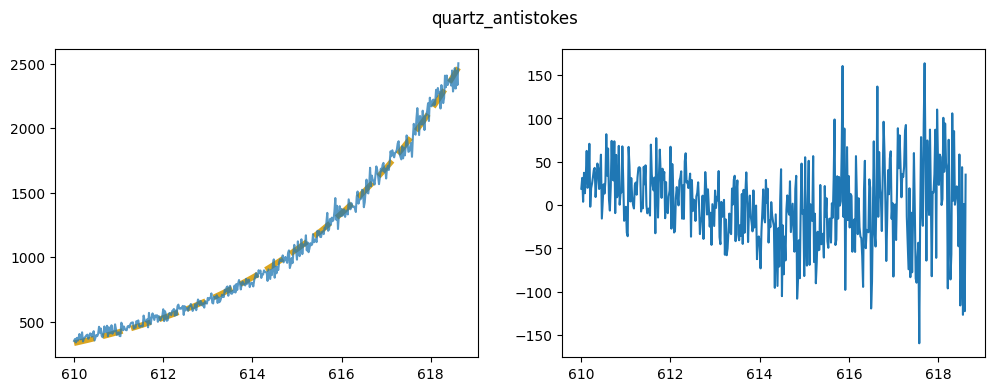

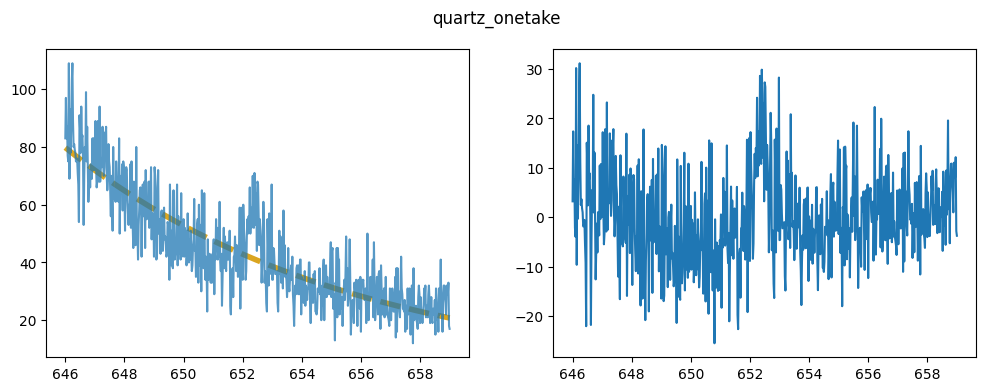

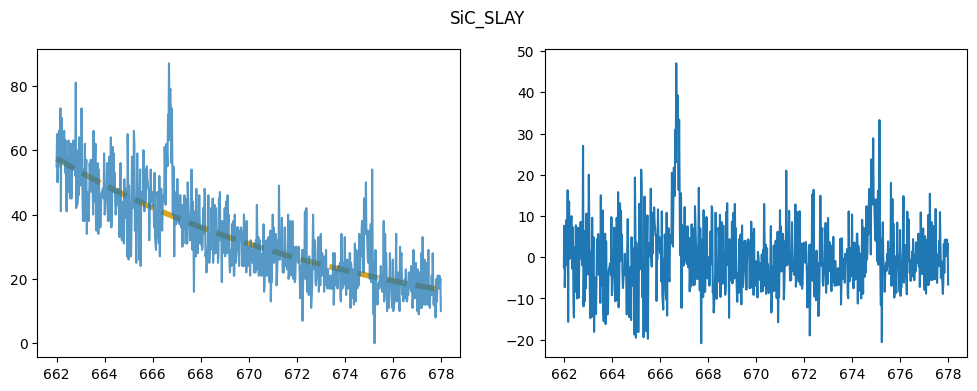

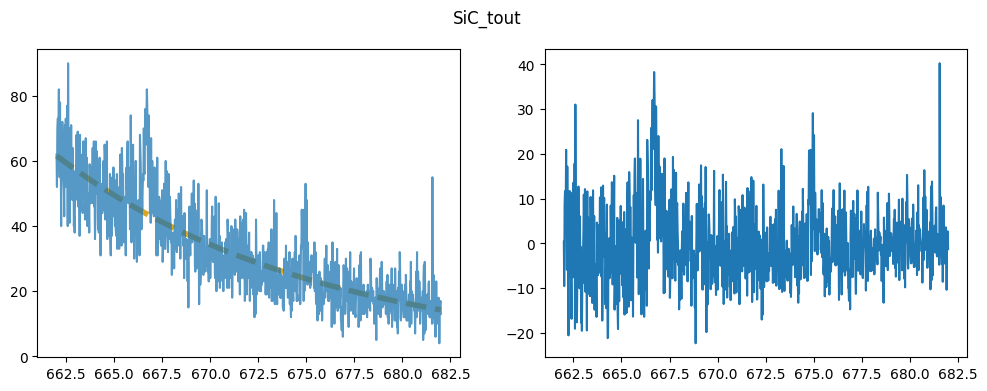

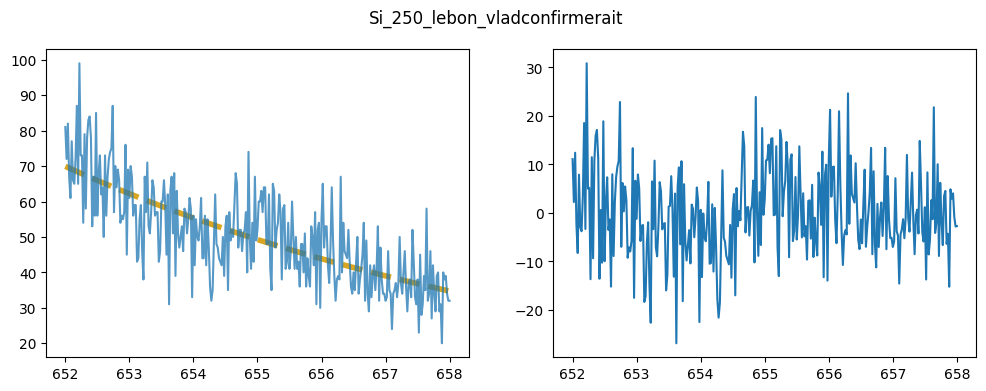

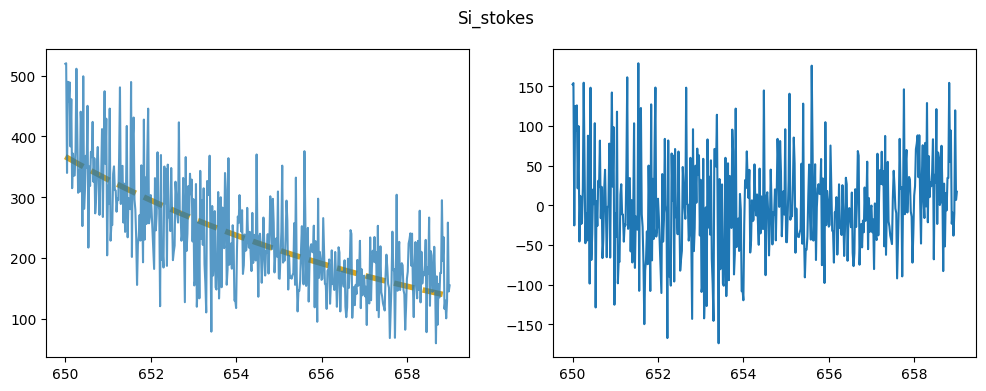

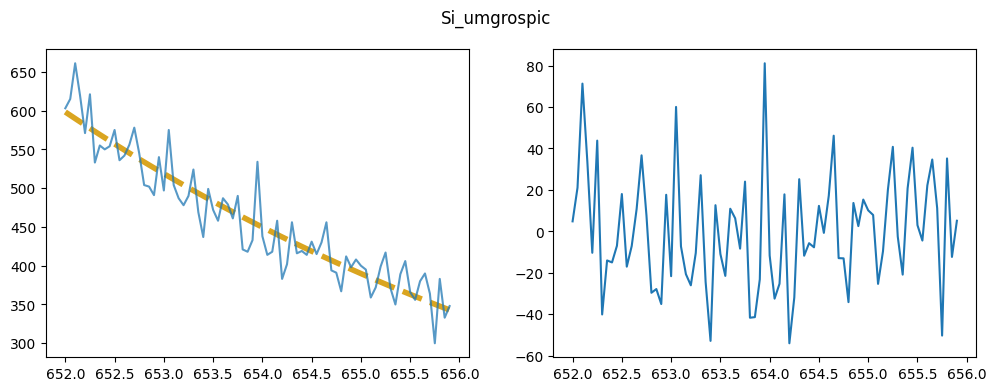

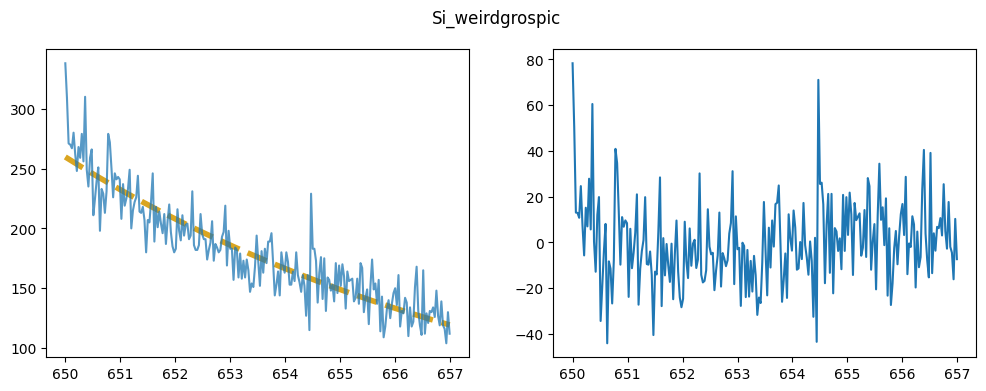

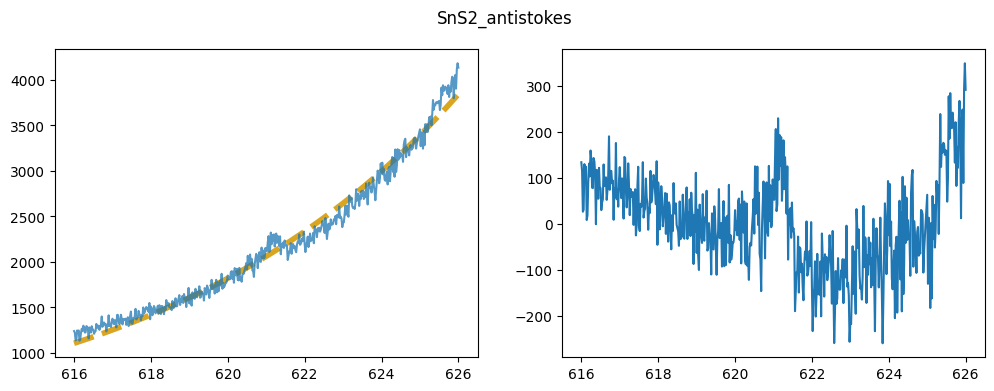

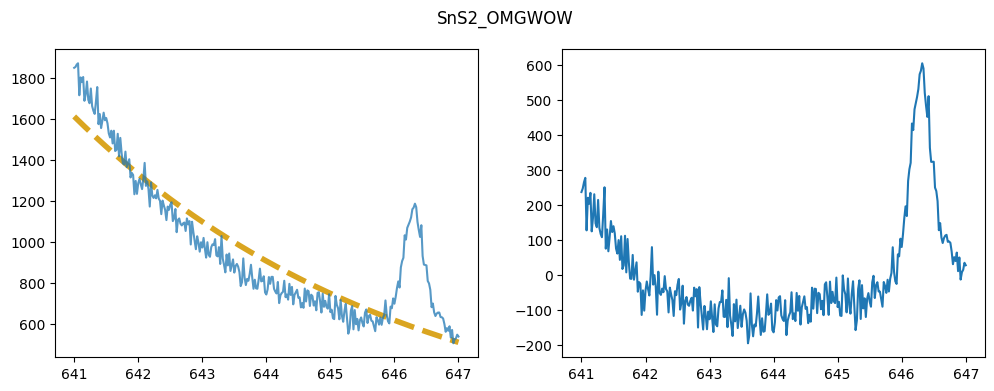

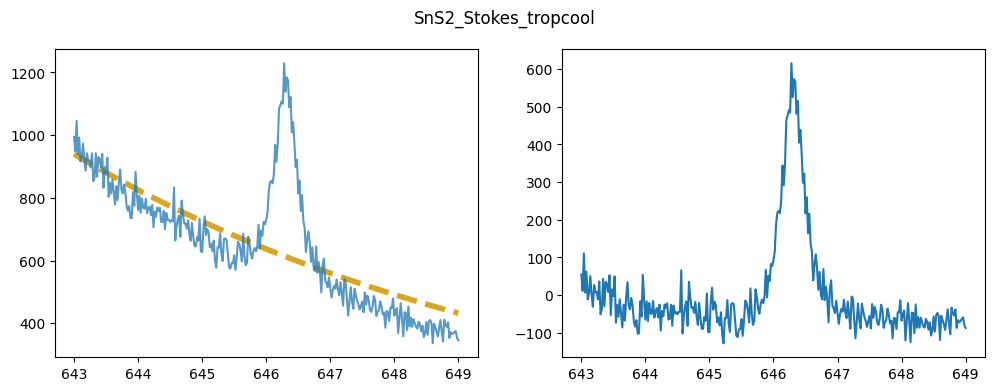

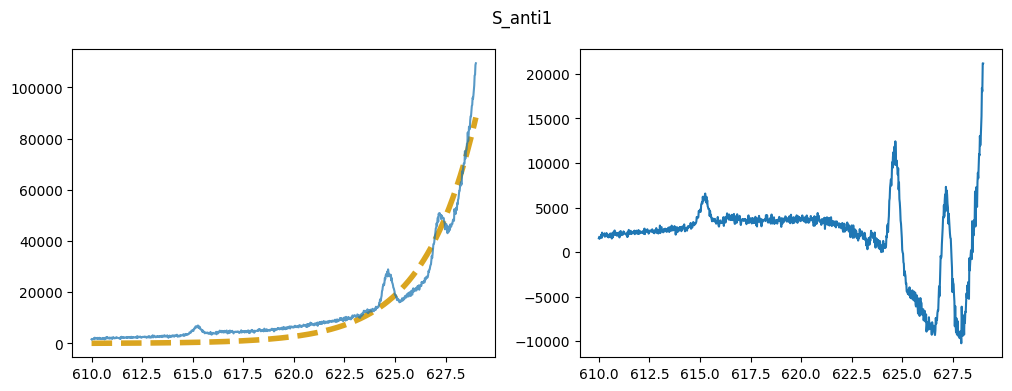

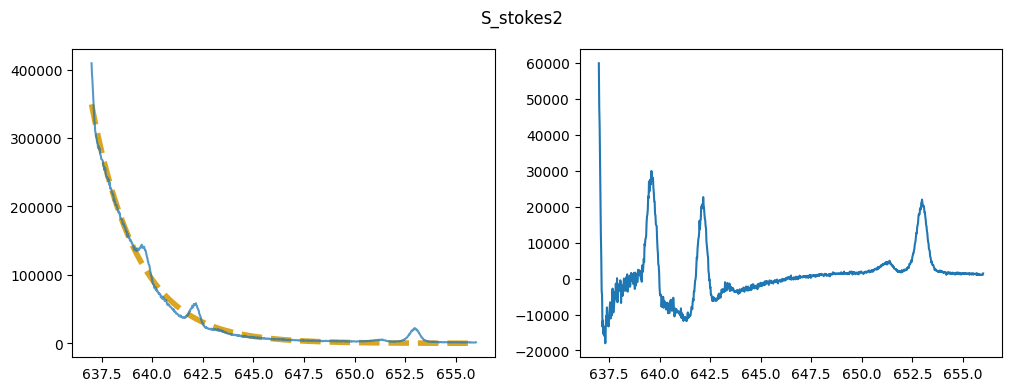

In [18]:
def courbe(x,a,b,c,d):
    return a*np.exp(-x*b)+c*np.exp(-x**2*d)

def exp(x,a,b,f):
    return a*np.exp(-(x-f)*b)

for i in donnees:
    spectre = np.loadtxt(f'donnees//RAM_AR_NS//{i}')
    if 'neon' in i:
        continue
    popt, pcov = curve_fit(exp, spectre[:,0], spectre[:,1],p0=[spectre[0,1],1,spectre[0,0]])
    print(popt)
    fig, ax = plt.subplots(1,2,figsize=(12,4))
    ax[0].plot(spectre[:,0], exp(spectre[:,0], *popt),linestyle='--',linewidth=4,color='goldenrod')
    ax[0].plot(spectre[:,0], spectre[:,1],alpha=.75)
    
    ax[1].plot(spectre[:,0], spectre[:,1]-exp(spectre[:,0], *popt))
    fig.suptitle(f'{i}')
    fig.show()

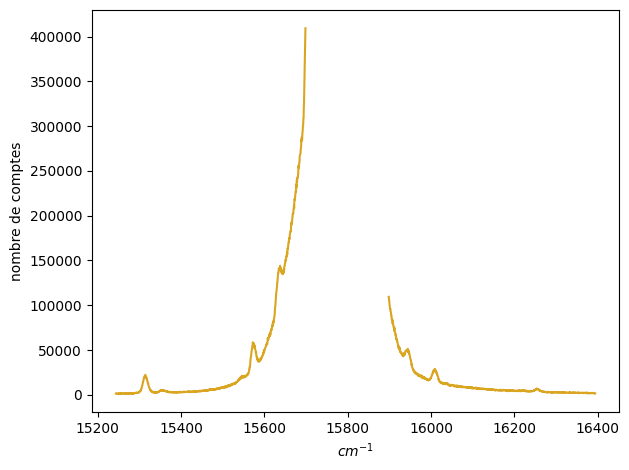

In [71]:
##Pour le Soufre##

for i in donnees:
    spectre = np.loadtxt(f'donnees//RAM_AR_NS//{i}')
    if 'S_' in i:
        plt.plot(1/(spectre[:,0]*1e-09*100), spectre[:,1],color='goldenrod')
    plt.ylabel('Intensité (comptes)')
    plt.xlabel(r'Décalage Raman $cm^{-1}$')
    plt.tight_layout()
    plt.savefig('soufre')


(array([9.66562294, 9.18338633]), array([16720.39, 52177.44]), array([205.02365328, 293.95556836]), array([214.68927622, 303.13895469]))
(array([15.41279413, 14.8003169 ]), array([ 35157.   , 117921.905]), array([211.61979167, 299.8679846 ]), array([227.0325858, 314.6683015]))
(array([5.67509182, 5.23132965]), array([ 9252.82, 30308.12]), array([213.22194988, 301.87757904]), array([218.8970417 , 307.10890869]))


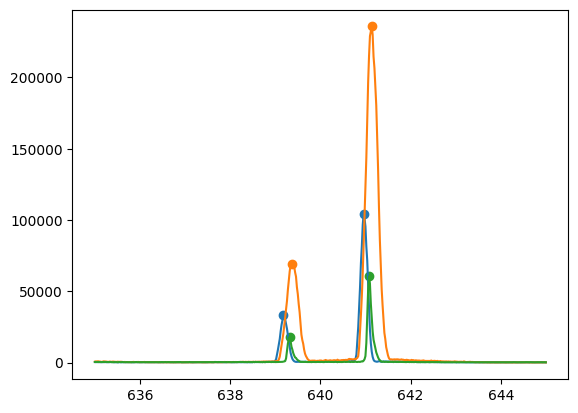

In [61]:
#pour l'étalonnage
for i in donnees:
    spectre = np.loadtxt(f'donnees//RAM_AR_NS//{i}')
    if 'neon' in i:
        peaks = find_peaks(spectre[:,1],height=10000,distance=5)
        FWHMs = peak_widths(spectre[:,1],peaks[0])

        plt.plot(spectre[:,0], spectre[:,1])
        plt.scatter(spectre[list(peaks[0]),0],peaks[1]['peak_heights'])
        
        print(FWHMs)

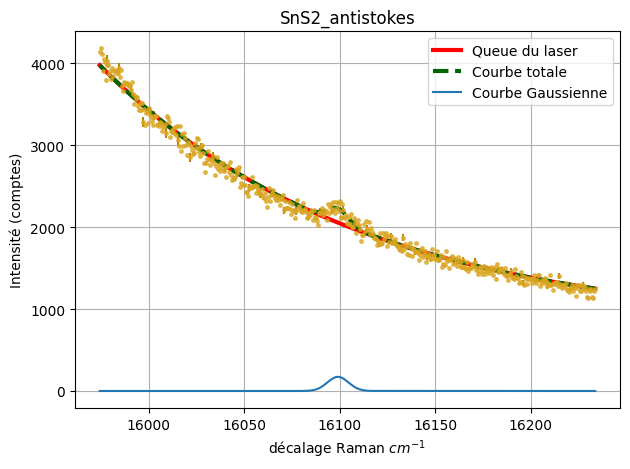

[ 7.50446363e+02  4.98806324e+02 -1.86710588e-01  1.72967949e+02
  6.21151278e+02  2.12119973e-01]


FileNotFoundError: donnees//RAM_AR_NS//SnS2_OMGWOW not found.

In [189]:
#échantillon3
def courbe_exp(x,c,Aexp,b,f):
    return c+ Aexp*np.exp(-(x-f)*b)

def courbe_gauss(x,c,Aexp,b,A,mu,sigma,f):
    return courbe_exp(x,c,Aexp,b,f) + A*np.exp(-0.5*((x-mu)/sigma)**2)

def fit_extreme(x,y,mus=None,peak_pad=0.4,weight_out=5):
    xref = np.min(x)
    xspan = np.ptp(x) if np.ptp(x) > 0 else 1.0

    if mus is None:
        prom = 0.05 * (np.max(y) - np.min(y))
        peaks, props = find_peaks(y, prominence=max(prom, 1.0)) #ici on essaye de trouver l'emplacement des pics pour se donner des valeurs de départs pour le fit
        idx = int(np.argmax(y)) if len(peaks) == 0 else peaks[np.argmax(props["prominences"])]
        mu_center = x[idx]
        mu_lo, mu_hi = mu_center - 0.5*xspan/15.0, mu_center + 0.5*xspan/15.0 #nous permet de trouver environ ou se trouve la gaussienne
    else:
        mu_lo, mu_hi = mus # si on veut la spécifier sinon
        
    #crée un masque qui cache la gaussienne pour faire la courbe de la queue
    excl_lo = mu_lo - peak_pad
    excl_hi = mu_hi + peak_pad
    mask_bg = (x < excl_lo) | (x > excl_hi)
    xb, yb = x[mask_bg], y[mask_bg]
    if xb.size < 6: #empêche de faire en sorte qu'on ai mal fitté tout et qu'on ait une mini région fausse
        xb, yb = x.copy(), y.copy()
        
    C0_g = np.percentile(yb, 10) #on se concentre sur les première valeurs pour trouver les paramètres départs
    Aexp_g = max(np.percentile(yb, 90) - C0_g, 1.0)
    slope = (yb[-1] - yb[0]) / max(xb[-1] - xb[0], 1e-12)
    b_g = np.sign(slope) * (1.0 / xspan)
    p0_bg = [C0_g, Aexp_g, b_g]
    
    def fit_queue(x,c,a,b):
        return courbe_exp(x,c,a,b,xref)
    
    param_queue,_ = curve_fit(fit_queue, xb, yb,p0=p0_bg,maxfev=200000)
    
    #ON VEUT MAINTENANT LA GAUSSIENNE UNIQUEMENT
    mask_pk = (x >= mu_lo) & (x <= mu_hi)
    xr = x[mask_pk]
    yr = (y - courbe_exp(x, *param_queue, xref))[mask_pk]
    
    #si on est pas capable d'avoir un range assez grand, on essaye de l'aggrandir plus
    if xr.size < 6:
        expand = 0.25
        mask_pk = (x >= mu_lo - expand) & (x <= mu_hi + expand)
        xr = x[mask_pk]
        yr = (y - courbe_exp(x, *param_queue, xref))[mask_pk]
    #s'il est trop petit on va juste enlever la courbe de la queue, moins précis mais mieux que rien
    if xr.size < 3:
        xr, yr = x.copy(), (y - courbe_exp(x, *param_queue, xref))
    
    #on trouve le max pour retrouver l'amplitude et le mu
    idx = np.argmax(yr)
    mu0 = float(np.clip(xr[idx], mu_lo, mu_hi)) #s'assurer qu'on reste dans le bon range
    A0 = max(yr[idx], 1.0)
    
    demi_h =yr[idx]/2
    G = idx
    while G>0 and yr[G]>demi_h: #permet de trouver la position gauche de la mi-hauteur
        G-=1
    D = idx
    while D<len(yr) -1 and yr[D]> demi_h: #meme chose mais pour le coté droit
        D+=1
    FWHM = xr[D]-xr[G]
    sigma0 = FWHM/2.355
    
    def fit_fonctionTot(x,c,Aexp,b,A,mu,sigma):
        return courbe_gauss(x,c,Aexp,b,A,mu,sigma,xref)
    
    p0_fonct = [*param_queue,A0,mu0,sigma0]
    sigmaw = np.ones_like(x)
    sigmaw[~mask_pk] = weight_out
    
    popt , cov_fonc = curve_fit(fit_fonctionTot,x,y,p0=p0_fonct,sigma=sigmaw,maxfev=500000)
    erreur  = np.sqrt(np.diag(cov_fonc))
    
    y_queue = courbe_exp(x,popt[0],popt[1],popt[2],xref)
    y_courbe = fit_fonctionTot(x,*popt)
    y_gauss = popt[3] *np.exp(-0.5* ((x-popt[4])/popt[5])**2)
    
    return {'popt':popt, 'perr':erreur, 'y_queue':y_queue, 'y_courbe':y_courbe, 'y_gauss':y_gauss}
    

for i in donnees:
    spectre = np.loadtxt(f'donnees//RAM_AR_NS//{i}')
    if 'Sn' in i:
        if 'anti' in i:
            mu = [620.5,621.5]
        else: mu = None
        X = spectre[:,0]
        Y = spectre[:,1]
        
        Résultat = fit_extreme(X,Y,mus=mu)
        
        marche = len(X)//40
        index_err = np.arange(0,len(X),marche)
        y_err = np.sqrt(Y)
        
        plt.errorbar(1/(X*1e-09*100), Y,marker='o',markersize=2.5,ls='',color='goldenrod',alpha=.75)
        plt.errorbar(1/(X[index_err]*1e-09*100),Y[index_err],yerr = y_err[index_err],marker='',color='darkgoldenrod',ls='')
        plt.plot(1/(X*1e-09*100),Résultat['y_queue'],label='Queue du laser',lw=3,color='red',ls='-')
        plt.plot(1/(X*1e-09*100),Résultat['y_courbe'],label='Courbe totale',lw=3,color='darkgreen',ls='--')
        plt.plot(1/(X*1e-09*100),Résultat['y_gauss'],label='Courbe Gaussienne')
        plt.legend(loc='best')
        plt.title(f'{i}')
        plt.ylabel('Intensité (comptes)')
        plt.xlabel('décalage Raman $cm^{-1}$')
        plt.tight_layout()
        plt.grid()
        plt.savefig(f'donnees//RAM_AR_NS//graphes//{i}')
        plt.show()
        
        print(Résultat['popt'])


np.int64(4)